# lapse_rate 模块演示与验证

本 Notebook 做两件事：

1. **演示怎么用**：读取已预处理的测试数据，调用两个算法，看输入/输出长什么样。
2. **验证算得对不对**：把迁移后的结果，和原 IMPROVER 方法、官方样例（KGO）做数值对比。

两个算法分别是：

- `LapseRate`：根据气温、地形、海陆掩码，**估计**网格上的层结递减率（单位 K/m，即高度每升高 1 米，气温大约降多少）。
- `ApplyGriddedLapseRate`：已经有递减率之后，按源地形与目标地形的高度差，**订正**气温。

官方样例是**投影坐标**网格，KGO 也是在投影输入上算出来的，所以**先看投影坐标输入**。  
后面的经纬坐标输入把同一套数据重网格到经纬，用来确认：算法改成 meb 六维之后，在真经纬输入上仍能和原方法对上。

请先在仓库根目录运行一次预处理（只需做一次，会写出 `cli_input/` 和 `latlon/`）：

```text
python 00temp/orographic_temperature_downscaling/cli/preprocess_test_data.py
```


## 1. 环境准备

下面几行只做三件事：找到本模块目录、让 Python 能 import 本仓库代码、打开中文绘图。


In [1]:
%matplotlib inline

from pathlib import Path
import sys
import warnings

import iris
import matplotlib.pyplot as plt
import meteva_base as meb
import numpy as np
import xarray as xr

# 屏蔽第三方库的过时提示，避免干扰阅读输出
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="pkg_resources is deprecated")

# 图里的中文、负号能正常显示
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "SimSun", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# 正式 notebook 位于 nbs/00space_downscale/orographic_temperature_downscaling/
# 数据仍在中间目录 00temp/orographic_temperature_downscaling/test_data/
NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT = None
for candidate in (NOTEBOOK_DIR, *NOTEBOOK_DIR.parents):
    if (candidate / "NIMM").is_dir() and (candidate / "00temp").is_dir():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError("未找到仓库根目录（需包含 NIMM/ 与 00temp/）。")

PACKAGE_ROOT = REPO_ROOT / "00temp" / "orographic_temperature_downscaling"
PROJECT_ROOT = REPO_ROOT
IMPROVER_ROOT = REPO_ROOT.parent / "improver" / "improver-1.18.7"

# 把仓库根目录和原 IMPROVER 副本加入搜索路径，后面才能 import
for path in (str(PROJECT_ROOT), str(IMPROVER_ROOT)):
    if path not in sys.path:
        sys.path.insert(0, path)

# 迁移后方法（读 meb 六维）
from importlib import import_module
_src = import_module("NIMM.00space_downscale.orographic_temperature_downscaling.lapse_rate")
ApplyGriddedLapseRate = _src.ApplyGriddedLapseRate
DALR = _src.DALR
ELR = _src.ELR
LapseRate = _src.LapseRate

# 原 IMPROVER 方法（读 Iris Cube），用来对照
from improver.temperature.lapse_rate import (  # noqa: E402
    ApplyGriddedLapseRate as OrigApplyGriddedLapseRate,
    LapseRate as OrigLapseRate,
)

print(f"干绝热递减率 DALR = {DALR} K/m（空气上升时，按干绝热过程降温的速率）")
print(f"环境递减率 ELR = {ELR} K/m（标准大气的平均降温速率）")
print(f"模块目录: {PACKAGE_ROOT}")


d:\workspace\improver\venv\Lib\site-packages\meteva_base\basicdata\const.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


干绝热递减率 DALR = -0.0098 K/m（空气上升时，按干绝热过程降温的速率）
环境递减率 ELR = -0.0065 K/m（标准大气的平均降温速率）
模块目录: D:\workspace\improver\temperature


## 2. 读数、对比、画图用的小工具

后面每组输入都会反复做三件事：读文件、比两个场差多少、画三张并排图。  
先把这些步骤写成函数，正文里就只剩“读哪些文件、调用哪个算法”。


In [2]:
# ---------- 数据目录 ----------
# ApplyGriddedLapseRate 用 apply_lapse_rate_data（气温订正）
# LapseRate 用 temp_lapse_rate_data（估计递减率）
APPLY_DATA_DIR = PACKAGE_ROOT / "test_data" / "apply_lapse_rate_data"
LAPSE_DATA_DIR = PACKAGE_ROOT / "test_data" / "temp_lapse_rate_data"

# 投影坐标：投影维只改了名字的 meb（给迁移方法 / CLI）
APPLY_CLI_INPUT_DIR = APPLY_DATA_DIR / "cli_input"
LAPSE_CLI_INPUT_DIR = LAPSE_DATA_DIR / "cli_input"
# 与 CLI 脚本底部相同的写出目录
APPLY_CLI_OUTPUT_DIR = APPLY_DATA_DIR / "cli_output"
LAPSE_CLI_OUTPUT_DIR = LAPSE_DATA_DIR / "cli_output"

# 经纬坐标：经纬 Cube（给原方法）和同源 meb（给迁移方法）
APPLY_LATLON_DIR = APPLY_DATA_DIR / "latlon"
LAPSE_LATLON_DIR = LAPSE_DATA_DIR / "latlon"
APPLY_LATLON_MEB_DIR = APPLY_LATLON_DIR / "cli_input"
LAPSE_LATLON_MEB_DIR = LAPSE_LATLON_DIR / "cli_input"

# 空间维可能叫 lat/lon，也可能仍是官方投影维名
SPATIAL_DIMS = (
    "lat",
    "lon",
    "latitude",
    "longitude",
    "projection_y_coordinate",
    "projection_x_coordinate",
)


def require_files(paths, label: str) -> None:
    """缺文件时给出明确提示，避免后面读盘才报一长串错误。"""
    missing = [str(p) for p in paths if not Path(p).exists()]
    if missing:
        raise FileNotFoundError(
            f"缺少{label}（共 {len(missing)} 个）。"
            "请先运行: python 00temp/orographic_temperature_downscaling/cli/preprocess_test_data.py\n"
            + "\n".join(missing[:8])
        )


def to_2d(data) -> np.ndarray:
    """把六维场或 Cube 压成一张二维图，方便比数值、画图。"""
    # 原 IMPROVER / 官方结果经常是 Iris Cube
    if not isinstance(data, xr.DataArray) and hasattr(data, "data"):
        raw = data.data
        if np.ma.isMaskedArray(raw):
            arr = np.ma.filled(np.ma.asarray(raw, dtype=np.float64), np.nan)
        else:
            arr = np.asarray(raw, dtype=np.float64)
        return np.squeeze(arr)

    # meb 六维：前四维通常长度为 1，取第 0 层就得到 lat×lon
    arr = data
    for dim in list(arr.dims):
        if dim not in SPATIAL_DIMS:
            arr = arr.isel({dim: 0}, drop=True)
    return np.squeeze(np.asarray(arr.values, dtype=np.float64))


def compare_stats(current, reference, tag: str):
    """打印两个场的差异。三个数都接近 0，说明两边几乎一样。"""
    left = to_2d(current)
    right = to_2d(reference)
    if left.shape != right.shape:
        raise ValueError(f"形状不一致: {left.shape} vs {right.shape}（{tag}）")
    diff = left - right
    print(
        f"[{tag}] "
        f"平均绝对误差={np.mean(np.abs(diff)):.8f}, "
        f"最大绝对误差={np.max(np.abs(diff)):.8f}, "
        f"均方根误差={np.sqrt(np.mean(diff ** 2)):.8f}"
    )
    return left, right, diff


def plot_fields(panels, *, title: str, cmap: str, unit: str, vmin=None, vmax=None):
    """并排画若干张空间图。panels 是 [(标题, 数据), ...]。

    同一组图共用色标，方便直接看三张图是否长得像。
    """
    arrays = [to_2d(data) for _, data in panels]
    if vmin is None:
        vmin = min(float(np.nanmin(a)) for a in arrays)
    if vmax is None:
        vmax = max(float(np.nanmax(a)) for a in arrays)

    fig, axes = plt.subplots(1, len(panels), figsize=(6 * len(panels), 4.8))
    if len(panels) == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=14)
    for ax, arr, (label, _) in zip(axes, arrays, panels):
        im = ax.imshow(arr, cmap=cmap, origin="lower", vmin=vmin, vmax=vmax)
        ax.set_title(label)
        fig.colorbar(im, ax=ax, fraction=0.046, label=unit)
    plt.tight_layout()
    plt.show()


def plot_pair_with_diff(left, right, *, title: str, cmap: str, unit: str,
                        left_label="修改后算法", right_label="原算法",
                        vmin=None, vmax=None):
    """左、中是两个结果（共用色标），右图是差值（越接近 0 越好）。"""
    a = to_2d(left)
    b = to_2d(right)
    diff = a - b
    if vmin is None:
        vmin = min(float(np.nanmin(a)), float(np.nanmin(b)))
    if vmax is None:
        vmax = max(float(np.nanmax(a)), float(np.nanmax(b)))
    # 差值色标以 0 为中心，正负对称
    dmax = float(np.nanmax(np.abs(diff)))
    dmax = dmax if dmax > 0 else 1e-12

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
    fig.suptitle(title, fontsize=14)
    for ax, arr, label, kw in (
        (axes[0], a, left_label, dict(cmap=cmap, vmin=vmin, vmax=vmax)),
        (axes[1], b, right_label, dict(cmap=cmap, vmin=vmin, vmax=vmax)),
        (axes[2], diff, "差值（左减中）", dict(cmap="RdBu_r", vmin=-dmax, vmax=dmax)),
    ):
        im = ax.imshow(arr, origin="lower", **kw)
        ax.set_title(label)
        fig.colorbar(im, ax=ax, fraction=0.046, label=unit)
    plt.tight_layout()
    plt.show()


print("工具函数已就绪。")


工具函数已就绪。


## 3. 投影坐标输入

这里读的是 `cli_input/`：投影坐标只是把维名改成了 `lat`/`lon`，**数值仍是米制投影**。  
迁移方法用 `meb.read_griddata_from_nc` 读六维网格；KGO 和原方法结果是官方 Iris 格式，用 `iris.load_cube` 读。三个数都接近 0，才算过关。


In [3]:
# 气温订正需要 4 个场：气温、递减率、源地形、目标地形
apply_paths = [
    APPLY_CLI_INPUT_DIR / "ukvx_temperature.nc",
    APPLY_CLI_INPUT_DIR / "ukvx_lapse_rate.nc",
    APPLY_CLI_INPUT_DIR / "ukvx_orography.nc",
    APPLY_CLI_INPUT_DIR / "highres_orog.nc",
]
# 估计递减率需要 3 个场：气温、地形、海陆掩码
lapse_paths = [
    LAPSE_CLI_INPUT_DIR / "temperature_at_screen_level.nc",
    LAPSE_CLI_INPUT_DIR / "ukvx_orography.nc",
    LAPSE_CLI_INPUT_DIR / "ukvx_landmask.nc",
]
require_files(apply_paths + lapse_paths, "投影坐标 meb")

# 迁移方法读 meb 六维 nc
apply_temperature = meb.read_griddata_from_nc(str(apply_paths[0]))
apply_lapse_rate = meb.read_griddata_from_nc(str(apply_paths[1]))
apply_source_orog = meb.read_griddata_from_nc(str(apply_paths[2]))
apply_dest_orog = meb.read_griddata_from_nc(str(apply_paths[3]))

lapse_temperature = meb.read_griddata_from_nc(str(lapse_paths[0]))
lapse_orog = meb.read_griddata_from_nc(str(lapse_paths[1]))
lapse_mask = meb.read_griddata_from_nc(str(lapse_paths[2]))

print("订正气温输入:", apply_temperature.dims, apply_temperature.shape)
print("估计递减率输入:", lapse_temperature.dims, lapse_temperature.shape)
apply_temperature  # 看一眼六维结构：坐标、单位、属性


订正气温输入: ('member', 'level', 'time', 'dtime', 'lat', 'lon') (1, 1, 1, 1, 100, 100)
估计递减率输入: ('member', 'level', 'time', 'dtime', 'lat', 'lon') (1, 1, 1, 1, 120, 110)


<xarray.DataArray 'air_temperature' (member: 1, level: 1, time: 1, dtime: 1,
                                     lat: 100, lon: 100)> Size: 40kB
array([[[[[[286.9542 , 286.92758, 286.89575, ..., 289.3587 ,
            289.37286, 289.37894],
           [286.94815, 286.9069 , 286.875  , ..., 289.64197,
            289.6126 , 289.57333],
           [286.92783, 286.88937, 286.8653 , ..., 289.46255,
            289.6153 , 289.81912],
           ...,
           [287.25034, 286.86206, 287.17783, ..., 287.26767,
            287.4298 , 287.48718],
           [287.3102 , 287.12085, 287.27722, ..., 287.2179 ,
            287.2345 , 287.38593],
           [287.07632, 287.3504 , 287.29144, ..., 286.21893,
            287.15488, 287.2539 ]]]]]],
      shape=(1, 1, 1, 1, 100, 100), dtype=float32)
Coordinates:
  * member   (member) <U5 20B 'data0'
  * level    (level) float32 4B 0.0
  * time     (time) datetime64[ns] 8B 1970-01-01
  * dtime    (dtime) int32 4B 0
  * lat      (lat) float64 800B 1.64e+05 1.66e+05 1.68e+05 ... 3.6e+05 3.62e+05
  * lon      (lon) float64 800B -2.58e+05 -2.56e+05 ... -6.2e+04 -6e+04
Attributes:
    units:               K
    dtime_units:         hour
    time_type:           UT
    title:               UKV Model Forecast on UK 2 km Standard Grid
    source:              Met Office Unified Model
    institution:         Met Office
    grid_mapping_attrs:  {"grid_mapping_name": "lambert_azimuthal_equal_area"...
    model_var:           
    level_type:          isobaric
    time_bounds:         [0, 0]

### 3.1 订正气温：`ApplyGriddedLapseRate`

含义：目标地形比源地形高时，按递减率把气温往下调（或反过来）。  
对照三列：迁移方法、官方 KGO、原算法。


=== 投影坐标：ApplyGriddedLapseRate ===
[修改后 vs KGO] 平均绝对误差=0.00000000, 最大绝对误差=0.00000000, 均方根误差=0.00000000
[修改后 vs 原算法] 平均绝对误差=0.00000000, 最大绝对误差=0.00000000, 均方根误差=0.00000000
[原算法 vs KGO] 平均绝对误差=0.00000000, 最大绝对误差=0.00000000, 均方根误差=0.00000000


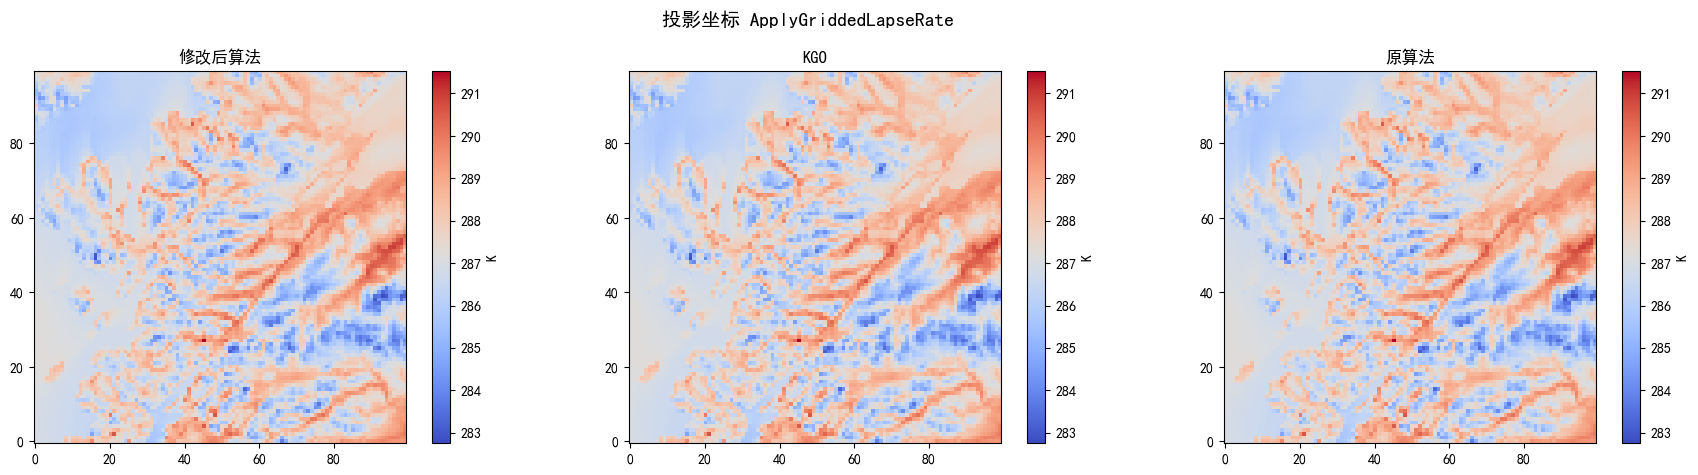

In [4]:
print("=== 投影坐标：ApplyGriddedLapseRate ===")

# 先创建算法对象，再立刻调用：四个场依次是 气温、递减率、源地形、目标地形
apply_modified = ApplyGriddedLapseRate()(
    apply_temperature, apply_lapse_rate, apply_source_orog, apply_dest_orog
)
# KGO / 原方法结果是官方 Iris 格式，每个文件里只有一个主变量
apply_kgo = iris.load_cube(str(APPLY_DATA_DIR / "kgo.nc"))
apply_original = iris.load_cube(str(APPLY_DATA_DIR / "original_algorithm_result.nc"))

compare_stats(apply_modified, apply_kgo, "修改后 vs KGO")
compare_stats(apply_modified, apply_original, "修改后 vs 原算法")
compare_stats(apply_original, apply_kgo, "原算法 vs KGO")

plot_fields(
    [("修改后算法", apply_modified), ("KGO", apply_kgo), ("原算法", apply_original)],
    title="投影坐标 ApplyGriddedLapseRate",
    cmap="coolwarm",
    unit="K",
)


### 3.2 估计递减率：`LapseRate`

含义：在每个格点邻域里，看气温随地形高度怎么变，得到 K/m。海洋点会落到干绝热递减率 DALR。


=== 投影坐标：LapseRate ===
[修改后 vs KGO] 平均绝对误差=0.00000000, 最大绝对误差=0.00000001, 均方根误差=0.00000000
[修改后 vs 原算法] 平均绝对误差=0.00000000, 最大绝对误差=0.00000001, 均方根误差=0.00000000
[原算法 vs KGO] 平均绝对误差=0.00000000, 最大绝对误差=0.00000000, 均方根误差=0.00000000


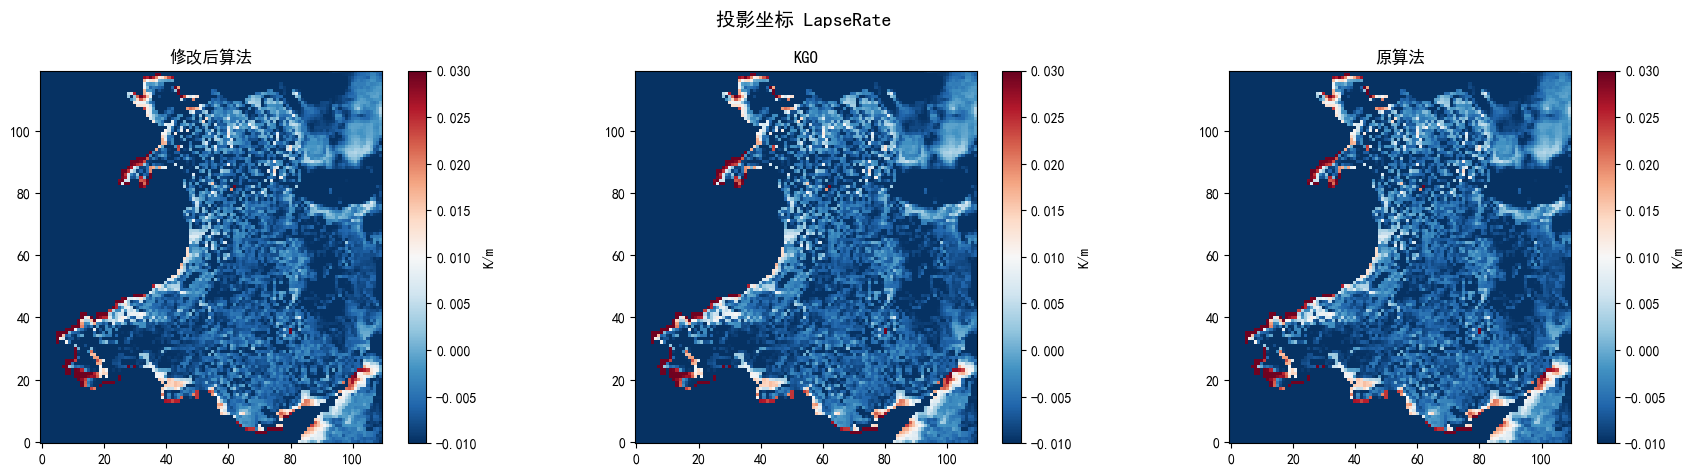

In [5]:
print("=== 投影坐标：LapseRate ===")

# 三个场：气温、地形高度、海陆掩码（陆地=1，海洋=0）
lapse_modified = LapseRate()(lapse_temperature, lapse_orog, lapse_mask)
lapse_kgo = iris.load_cube(str(LAPSE_DATA_DIR / "kgo.nc"))
lapse_original = iris.load_cube(str(LAPSE_DATA_DIR / "original_lapse_rate_result.nc"))

compare_stats(lapse_modified, lapse_kgo, "修改后 vs KGO")
compare_stats(lapse_modified, lapse_original, "修改后 vs 原算法")
compare_stats(lapse_original, lapse_kgo, "原算法 vs KGO")

plot_fields(
    [("修改后算法", lapse_modified), ("KGO", lapse_kgo), ("原算法", lapse_original)],
    title="投影坐标 LapseRate",
    cmap="RdBu_r",
    unit="K/m",
    vmin=-0.01,
    vmax=0.03,
)


## 4. 经纬坐标输入

`latlon/` 是投影转经纬并重网格后的 **Iris Cube**（原方法吃这个）；  
`latlon/cli_input/` 是同一套数值的 **meb**（迁移方法吃这个）。  

这里**不和投影 KGO 比**（网格已经变了），只看：修改后 vs 原方法。


In [6]:
# 同一套经纬场有两份文件：Cube 给原方法，meb 给迁移方法
apply_ll_cube_paths = [
    APPLY_LATLON_DIR / "ukvx_temperature.nc",
    APPLY_LATLON_DIR / "ukvx_lapse_rate.nc",
    APPLY_LATLON_DIR / "ukvx_orography.nc",
    APPLY_LATLON_DIR / "highres_orog.nc",
]
apply_ll_meb_paths = [
    APPLY_LATLON_MEB_DIR / "ukvx_temperature.nc",
    APPLY_LATLON_MEB_DIR / "ukvx_lapse_rate.nc",
    APPLY_LATLON_MEB_DIR / "ukvx_orography.nc",
    APPLY_LATLON_MEB_DIR / "highres_orog.nc",
]
lapse_ll_cube_paths = [
    LAPSE_LATLON_DIR / "temperature_at_screen_level.nc",
    LAPSE_LATLON_DIR / "ukvx_orography.nc",
    LAPSE_LATLON_DIR / "ukvx_landmask.nc",
]
lapse_ll_meb_paths = [
    LAPSE_LATLON_MEB_DIR / "temperature_at_screen_level.nc",
    LAPSE_LATLON_MEB_DIR / "ukvx_orography.nc",
    LAPSE_LATLON_MEB_DIR / "ukvx_landmask.nc",
]
require_files(apply_ll_cube_paths + lapse_ll_cube_paths, "经纬坐标 Cube")
require_files(apply_ll_meb_paths + lapse_ll_meb_paths, "经纬坐标 meb")

# 迁移方法读 meb；原方法读 Iris Cube
apply_temperature_ll = meb.read_griddata_from_nc(str(apply_ll_meb_paths[0]))
apply_lapse_rate_ll = meb.read_griddata_from_nc(str(apply_ll_meb_paths[1]))
apply_source_orog_ll = meb.read_griddata_from_nc(str(apply_ll_meb_paths[2]))
apply_dest_orog_ll = meb.read_griddata_from_nc(str(apply_ll_meb_paths[3]))
apply_temperature_cube = iris.load_cube(str(apply_ll_cube_paths[0]))
apply_lapse_rate_cube = iris.load_cube(str(apply_ll_cube_paths[1]))
apply_source_orog_cube = iris.load_cube(str(apply_ll_cube_paths[2]))
apply_dest_orog_cube = iris.load_cube(str(apply_ll_cube_paths[3]))

lapse_temperature_ll = meb.read_griddata_from_nc(str(lapse_ll_meb_paths[0]))
lapse_orog_ll = meb.read_griddata_from_nc(str(lapse_ll_meb_paths[1]))
lapse_mask_ll = meb.read_griddata_from_nc(str(lapse_ll_meb_paths[2]))
lapse_temperature_cube = iris.load_cube(str(lapse_ll_cube_paths[0]))
lapse_orog_cube = iris.load_cube(str(lapse_ll_cube_paths[1]))
lapse_mask_cube = iris.load_cube(str(lapse_ll_cube_paths[2]))

print("经纬坐标订正气温 meb:", apply_temperature_ll.dims, apply_temperature_ll.shape)
print("经纬 Cube 形状:", apply_temperature_cube.shape)


经纬坐标订正气温 meb: ('member', 'level', 'time', 'dtime', 'lat', 'lon') (1, 1, 1, 1, 100, 100)
经纬 Cube 形状: (100, 100)


### 4.1 订正气温（经纬）


=== 经纬坐标：ApplyGriddedLapseRate ===
[修改后 vs 原算法] 平均绝对误差=0.00000000, 最大绝对误差=0.00000000, 均方根误差=0.00000000
[输入气温 meb vs Cube] 平均绝对误差=0.00000000, 最大绝对误差=0.00000000, 均方根误差=0.00000000


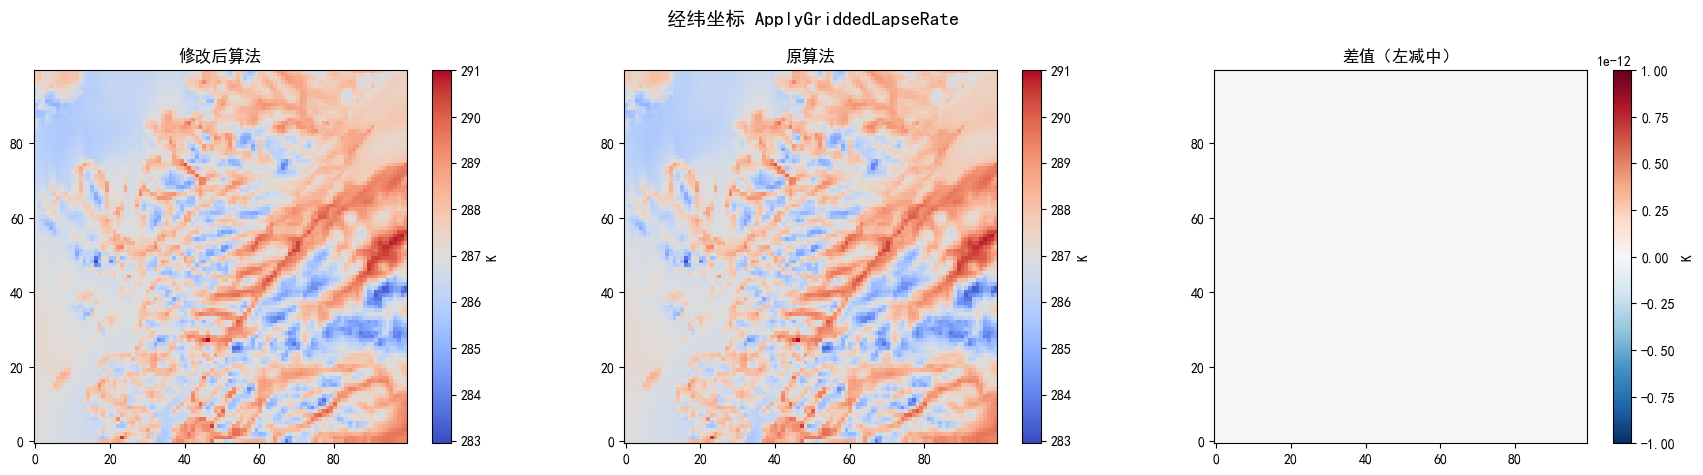

In [7]:
print("=== 经纬坐标：ApplyGriddedLapseRate ===")

apply_modified_ll = ApplyGriddedLapseRate()(
    apply_temperature_ll, apply_lapse_rate_ll, apply_source_orog_ll, apply_dest_orog_ll
)
# 原方法接口是 .process(Cube, ...)
apply_original_ll = OrigApplyGriddedLapseRate().process(
    apply_temperature_cube,
    apply_lapse_rate_cube,
    apply_source_orog_cube,
    apply_dest_orog_cube,
)

compare_stats(apply_modified_ll, apply_original_ll, "修改后 vs 原算法")
# 顺便确认：同一份经纬场，meb 和 Cube 数值一致
compare_stats(apply_temperature_ll, apply_temperature_cube, "输入气温 meb vs Cube")

plot_pair_with_diff(
    apply_modified_ll,
    apply_original_ll,
    title="经纬坐标 ApplyGriddedLapseRate",
    cmap="coolwarm",
    unit="K",
)


### 4.2 估计递减率（经纬）


=== 经纬坐标：LapseRate ===
[修改后 vs 原算法] 平均绝对误差=0.00000000, 最大绝对误差=0.00000001, 均方根误差=0.00000000


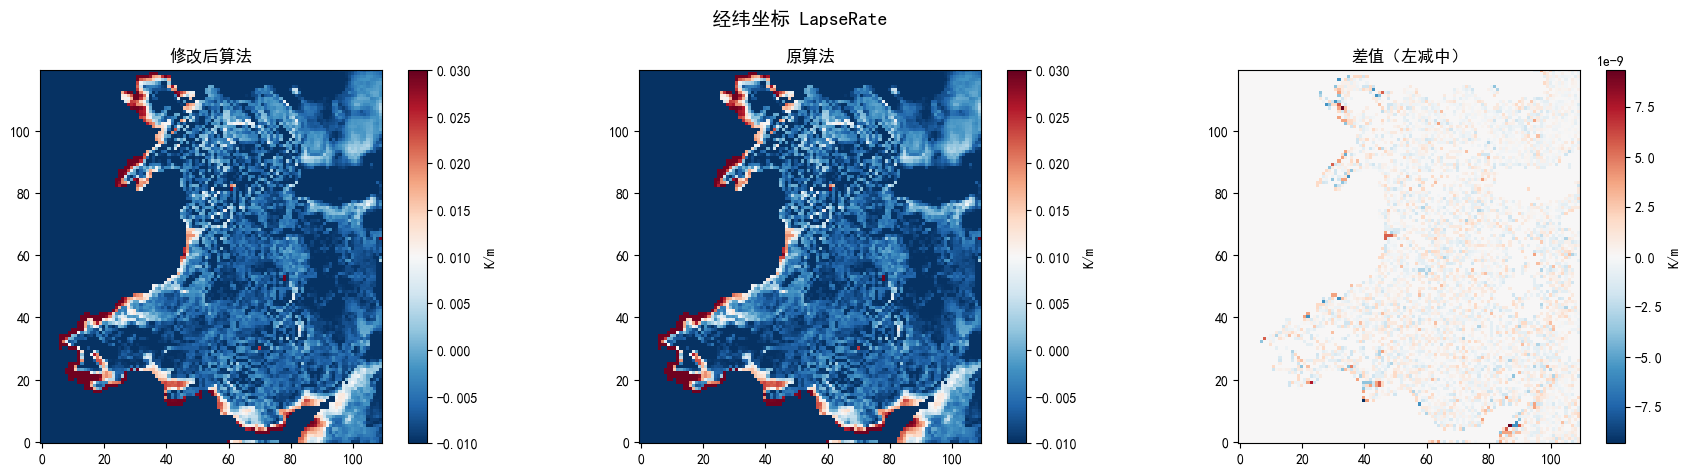

In [8]:
print("=== 经纬坐标：LapseRate ===")

lapse_modified_ll = LapseRate()(lapse_temperature_ll, lapse_orog_ll, lapse_mask_ll)
lapse_original_ll = OrigLapseRate().process(
    lapse_temperature_cube, lapse_orog_cube, lapse_mask_cube
)

compare_stats(lapse_modified_ll, lapse_original_ll, "修改后 vs 原算法")

plot_pair_with_diff(
    lapse_modified_ll,
    lapse_original_ll,
    title="经纬坐标 LapseRate",
    cmap="RdBu_r",
    unit="K/m",
    vmin=-0.01,
    vmax=0.03,
)


## 5. CLI 示例

CLI 脚本的入口函数 `process()` 接收的是 **nc 文件路径**。  
脚本内部会自己读盘、调用算法，并把结果写到与脚本底部相同的 `cli_output/` 文件。

下面用投影坐标的 `cli_input/` 演示调用，并与 KGO / 原 CLI 结果对照。终端里也可以直接跑（先改脚本底部的路径）：

```text
python cli/00space_downscale/orographic_temperature_downscaling/anc_lapse_rate_main.py
python cli/00space_downscale/orographic_temperature_downscaling/dsc_temp_lapse_rate_main.py
```


### 5.1 订正气温 CLI：`anc_lapse_rate_main.py`


已写出: D:\workspace\improver\temperature\test_data\apply_lapse_rate_data\cli_output\cli_apply_lapse_rate_result.nc
[修改后 CLI vs 原 CLI] 平均绝对误差=0.00000000, 最大绝对误差=0.00000000, 均方根误差=0.00000000
[修改后 CLI vs KGO] 平均绝对误差=0.00000000, 最大绝对误差=0.00000000, 均方根误差=0.00000000
[原 CLI vs KGO] 平均绝对误差=0.00000000, 最大绝对误差=0.00000000, 均方根误差=0.00000000


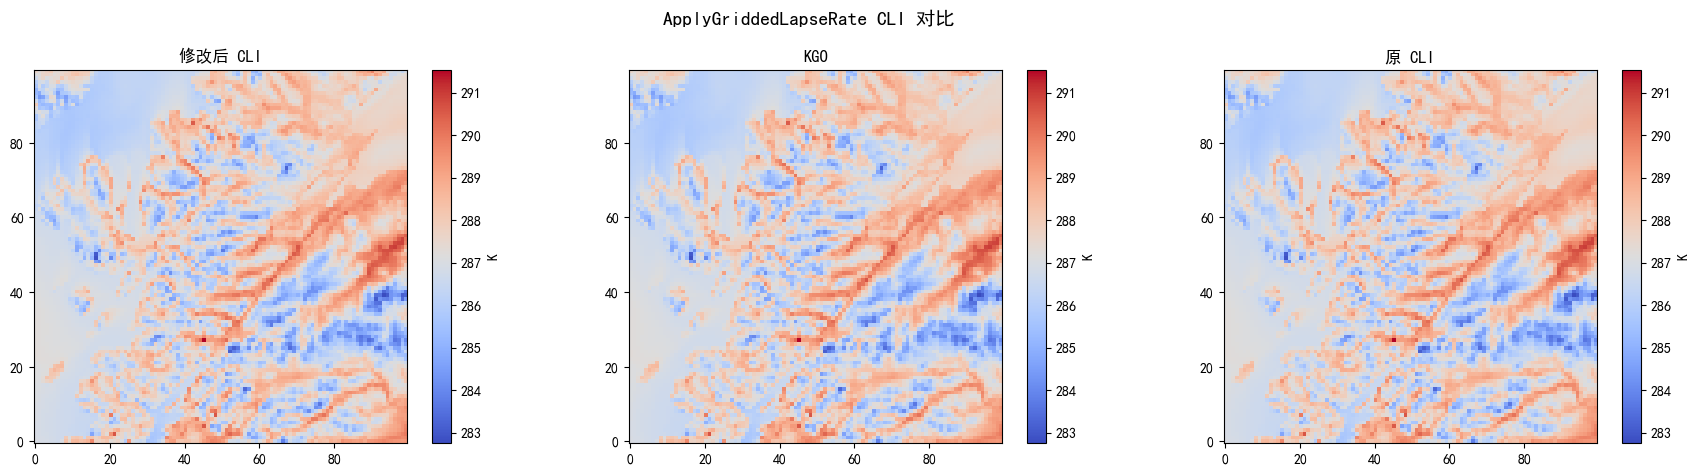

In [9]:
from importlib import import_module
_cli = import_module("cli.00space_downscale.orographic_temperature_downscaling.anc_lapse_rate_main")
process = _cli.process

# 写出路径与 anc_lapse_rate_main.py 脚本底部一致
apply_output_path = APPLY_CLI_OUTPUT_DIR / "cli_apply_lapse_rate_result.nc"
cli_apply = apply_cli(
    str(APPLY_CLI_INPUT_DIR / "ukvx_temperature.nc"),
    str(APPLY_CLI_INPUT_DIR / "ukvx_lapse_rate.nc"),
    str(APPLY_CLI_INPUT_DIR / "ukvx_orography.nc"),
    str(APPLY_CLI_INPUT_DIR / "highres_orog.nc"),
    output_path=str(apply_output_path),
)
print(f"已写出: {apply_output_path}")
orig_cli_apply = iris.load_cube(str(APPLY_DATA_DIR / "original_cli_result.nc"))

compare_stats(cli_apply, orig_cli_apply, "修改后 CLI vs 原 CLI")
compare_stats(cli_apply, apply_kgo, "修改后 CLI vs KGO")
compare_stats(orig_cli_apply, apply_kgo, "原 CLI vs KGO")

plot_fields(
    [("修改后 CLI", cli_apply), ("KGO", apply_kgo), ("原 CLI", orig_cli_apply)],
    title="ApplyGriddedLapseRate CLI 对比",
    cmap="coolwarm",
    unit="K",
)


### 5.2 估计递减率 CLI：`dsc_temp_lapse_rate_main.py`


已写出: D:\workspace\improver\temperature\test_data\temp_lapse_rate_data\cli_output\cli_lapse_rate_result.nc
[修改后 CLI vs KGO] 平均绝对误差=0.00000000, 最大绝对误差=0.00000001, 均方根误差=0.00000000
[修改后 CLI vs 原 CLI] 平均绝对误差=0.00000000, 最大绝对误差=0.00000001, 均方根误差=0.00000000
[原 CLI vs KGO] 平均绝对误差=0.00000000, 最大绝对误差=0.00000000, 均方根误差=0.00000000


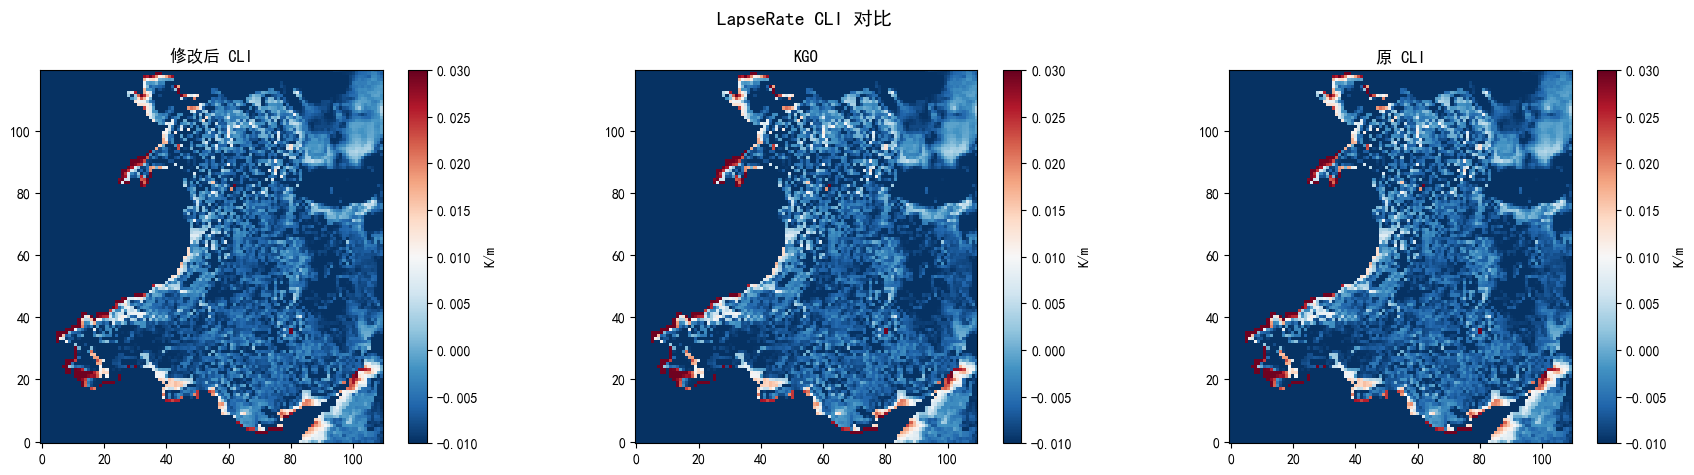

In [10]:
from importlib import import_module
_cli = import_module("cli.00space_downscale.orographic_temperature_downscaling.dsc_temp_lapse_rate_main")
process = _cli.process

# 写出路径与 dsc_temp_lapse_rate_main.py 脚本底部一致
lapse_output_path = LAPSE_CLI_OUTPUT_DIR / "cli_lapse_rate_result.nc"
cli_lapse = lapse_cli(
    str(LAPSE_CLI_INPUT_DIR / "temperature_at_screen_level.nc"),
    str(LAPSE_CLI_INPUT_DIR / "ukvx_orography.nc"),
    str(LAPSE_CLI_INPUT_DIR / "ukvx_landmask.nc"),
    output_path=str(lapse_output_path),
)
print(f"已写出: {lapse_output_path}")
orig_cli_lapse = iris.load_cube(str(LAPSE_DATA_DIR / "original_cli_result.nc"))

compare_stats(cli_lapse, lapse_kgo, "修改后 CLI vs KGO")
compare_stats(cli_lapse, orig_cli_lapse, "修改后 CLI vs 原 CLI")
compare_stats(orig_cli_lapse, lapse_kgo, "原 CLI vs KGO")

plot_fields(
    [("修改后 CLI", cli_lapse), ("KGO", lapse_kgo), ("原 CLI", orig_cli_lapse)],
    title="LapseRate CLI 对比",
    cmap="RdBu_r",
    unit="K/m",
    vmin=-0.01,
    vmax=0.03,
)
